In [4]:
# Libraries

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, mean_squared_error
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error, mean_squared_percentage_error, median_absolute_percentage_error


In [5]:
# 1. Data generation

def calculate_braking_distance(v_kmh, mu, t_reaction, g):
    """
    Calculates the total braking distance for a vehicle.

    Solves the braking distance equation
    d_total = v * t_reaction + (v^2) / (2 * mu * g)
    for distance d, returning the total stopping distance.

    Args:
      v_kmh (float): Initial velocity of the vehicle (km/h).
      mu (float): Coefficient of tire-pavement friction.
      g (float): Acceleration due to gravity (9.81 m/s^2).
      t_reaction (float): Driver's reaction time (0.9s by default).

    Returns:
      d (float): Total braking distance (m).
    """

    v = v_kmh / 3.6
    if mu <= 0:
        return None
    d_total = v * t_reaction + (v**2) / (2 * mu * g)
    return d_total


# Parameters
g = 9.81 # m/s^2
n_samples = 1000
v_kmh = np.random.uniform(0, 120, n_samples) # speeds between 0km/s and 120km/s
mu = np.random.uniform(0.3, 0.9, n_samples) # typical coefficient of friction on pavement
t_reaction = np.random.uniform(0.5, 2.0, n_samples) # reaction between 0.5s and 2s


data = []
for i in range(n_samples):
  d = calculate_braking_distance(v_kmh[i], mu[i], t_reaction[i], g)
  if d is not None and d > 0:
    data.append([v_kmh[i], mu[i], t_reaction[i],d])

# Convert to numpy for AI model
data = np.array(data)

print(data)


[[ 74.55084825   0.75527052   1.25579119  54.94564602]
 [ 86.00504783   0.79574379   1.31906766  68.06991627]
 [ 89.09153161   0.48957699   1.87040578 110.04807551]
 ...
 [ 44.13671749   0.82535493   0.885829    20.14273382]
 [113.85400695   0.83085153   1.02890152  93.89787576]
 [ 49.42911234   0.5036014    1.066134    33.71818729]]


In [6]:
# 2. Data splitting

# Split into train_val (80%) and test (20%)
train_val_set, test_set = train_test_split(data, test_size = 0.2)

# Split into train (80%) and val (20%)
train_set, val_set = train_test_split(train_val_set, test_size = 0.2)


# Split into x and y
x_train = train_set[:, :3]
y_train = train_set[:, 3]
x_val = val_set[:, :3]
y_val = val_set[:, 3]
x_test = test_set[:, :3]
y_test = test_set[:, 3]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)


(640, 3) (640,)
(160, 3) (160,)
(200, 3) (200,)


In [7]:
# 3. Data preprocessing

# Apply normalization to our features (v_kmh, mu, t_reaction)
x_scaler = StandardScaler()
x_train_scaled = x_scaler.fit_transform(x_train)
x_val_scaled = x_scaler.transform(x_val)
x_test_scaled = x_scaler.transform(x_test)

# Apply normalization to our output (d)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1))
y_val_scaled = y_scaler.transform(y_val.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1))


In [46]:
# 4. Designing our model

def functional_model(input_dim):
    """ Build a 3-layer MLP

    This is a model built with the Functional model from the keras library. The
    Functional block has four layers, one input layer, two hideen layers and an
    output layer. The output layer approximate the physical braking distance
    equation of a vehicle. This model takes as inputs the three main variables
    of our problem: initial speed (m/s), tire-pavement friction coefficient and
    driver reaction time (s). Based on these inputs, the network predicts the
    total braking distance (m), which is physically defined by the relation:
    d = v * t_reaction + (v^2) / (2 * μ * g)

    Arg:
     input_dim (int): Input dimension, number of features (3 in our case)

    Returns:
     model (Model): Functional model ready for training

    """
    inputs = Input(shape=(input_dim,), name = "input")
    x = Dense(32, activation = "silu", input_dim = input_dim, name = "Hidden1")(inputs)
    x = Dense(8, activation = "silu", name = "Hidden2")(x)
    outputs = Dense(1, activation="linear", name = "Output_layer")(x)

    model = Model(inputs = inputs, outputs = outputs)

    return model


In [47]:
# 4. Compile and train our model

model = functional_model(input_dim = 3)
model.compile(optimizer = Adam(learning_rate = 0.001), loss = "mse", metrics = ["mae"])

history = model.fit(x = x_train_scaled, y = y_train_scaled, validation_data = (x_val_scaled, y_val_scaled), epochs = 70, batch_size = 32)


Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.8507 - mae: 0.7636 - val_loss: 0.7064 - val_mae: 0.7114
Epoch 2/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6544 - mae: 0.6656 - val_loss: 0.4946 - val_mae: 0.5988
Epoch 3/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4607 - mae: 0.5583 - val_loss: 0.3029 - val_mae: 0.4700
Epoch 4/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2633 - mae: 0.4289 - val_loss: 0.1585 - val_mae: 0.3342
Epoch 5/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1486 - mae: 0.3165 - val_loss: 0.0649 - val_mae: 0.2085
Epoch 6/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0563 - mae: 0.1921 - val_loss: 0.0225 - val_mae: 0.1133
Epoch 7/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0188 - mae: 0.1002 - val_loss: 0.0096 - val_mae: 0.0641
Epoch 8/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - mae: 0.0595 - val_loss: 0.0077 - val_mae: 0.0534
Epoch 9/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0070 - mae: 0.0581 - v

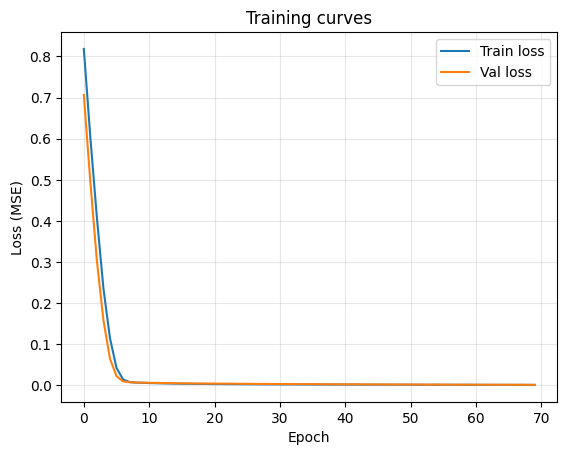

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


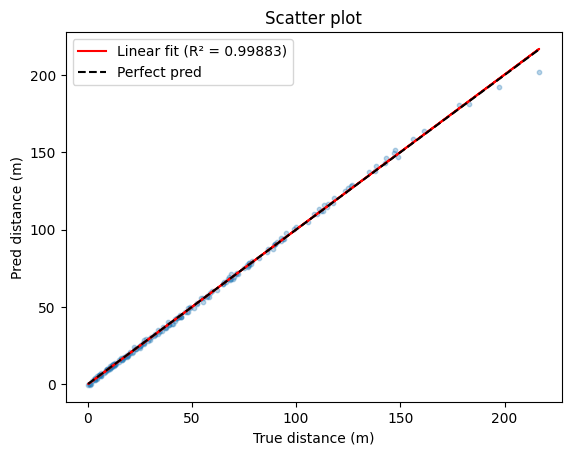

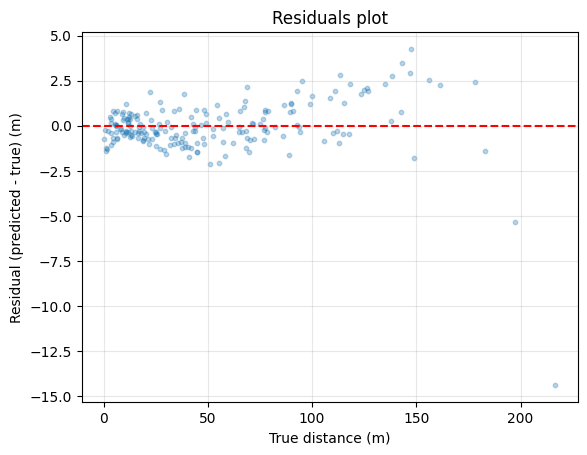

None


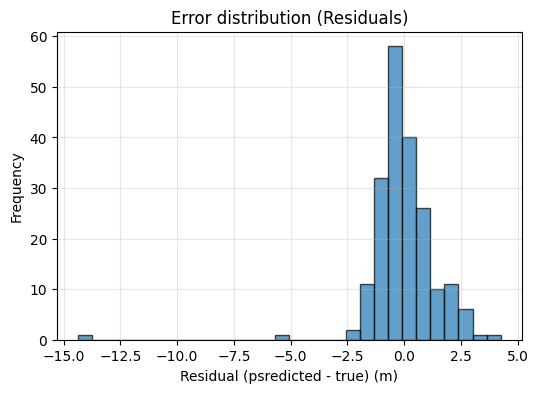

None
Further evaluation:


{'MAE': 0.9237315318632091,
 'Median AE': 0.6955441709291681,
 'MSE': 2.358316239417677,
 'R2': 0.9988276174801749,
 'MAPE (%)': 6.332490667131273,
 'MSPE (%)': 7.335843068450284,
 'MedAPE (%)': 1.9464900955120898}

In [48]:
# 5. Evaluate our model

def plot_training_curves(history):
    """
    This function plots the training and validation loss curves.

    This helps to check if training went correctly and to spot
    possible overfitting or underfitting. A large gap between
    training and validation loss can indicate overfitting.

    Args:
    - history (keras history): history of my model.
    """

    plt.plot(history.history["loss"], label = "Train loss")
    plt.plot(history.history["val_loss"], label = "Val loss")
    plt.title("Training curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_scatter(y_test, y_pred):
    """
    Scatter plot of true vs predicted values.

    This plot helps to visually evaluate how well the model
    predictions match the actual braking distances.

    Args:
        y_test (array): True values.
        y_pred (array): Predicted values.

    Returns:
        r2 (float): R-squared score of the predictions.
    """

    linear_regression = LinearRegression().fit(y_test.reshape(-1, 1), y_pred.reshape(-1, 1))
    y_fit = linear_regression.predict(y_test.reshape(-1, 1))

    r2 = r2_score(y_test, y_pred)

    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.3, s=10)
    plt.plot(y_test, y_fit, "-r", label = f"Linear fit (R² = {round(r2, 5)})")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--k", label = "Perfect pred")
    plt.title("Scatter plot")
    plt.xlabel("True distance (m)")
    plt.ylabel("Pred distance (m)")
    plt.legend()

    return r2

plot_training_curves(history)

y_pred_scaled = model.predict(x_test_scaled)
y_pred_scaled = np.array(y_pred_scaled).reshape(-1,1)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

r2 = plot_scatter(y_test, y_pred)


def plot_residuals(y_test, y_pred):
    """
    Plot the residuals of the model predictions.

    This function calculates the residuals, which are the differences
    between predicted and true values, and plots them against the true values.
    It helps to visualize whether the model errors are randomly distributed
    or show some pattern, indicating potential bias or issues with the model.

    Args:
        y_test (array): True target values.
        y_pred (array): Predicted target values.
    """

    y_test_flat = y_test.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    residuals = y_pred_flat - y_test_flat
    plt.figure()
    plt.scatter(y_test.reshape(-1), residuals, alpha = 0.3, s = 10)
    plt.axhline(0, color = 'r', linestyle = '--')
    plt.title("Residuals plot")
    plt.xlabel("True distance (m)")
    plt.ylabel("Residual (predicted - true) (m)")
    plt.grid(True, alpha = 0.3)
    plt.show()

print(plot_residuals(y_test, y_pred))


def plot_error_histogram(y_test, y_pred):
    """
    Plot histogram of residuals (prediction errors).

    This shows how the model errors are distributed,
    helping to detect bias or outliers.

    Args:
        y_test (array): True distances.
        y_pred (array): Predicted distances.
    """
    residuals = y_pred.reshape(-1) - y_test.reshape(-1)

    plt.figure(figsize = (6, 4))
    plt.hist(residuals, bins = 30, edgecolor = 'black', alpha = 0.7)
    plt.title("Error distribution (Residuals)")
    plt.xlabel("Residual (psredicted - true) (m)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha = 0.3)
    plt.show()

print(plot_error_histogram(y_test, y_pred))


def further_evaluation(y_test, y_pred, r2):
    """
    Calculate main regression metrics for the test set.

    This function computes metrics on the test predictions,
    which are different from the metrics obtained during training.

    Args:
        y_test (float): True values.
        y_pred (float): Predicted values.
        r2 (float): R-squared score.

    Returns:
        dict: Dictionary with key metrics.
    """

    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "Median AE": float(median_absolute_error(y_test, y_pred)),
        "MSE": mean_squared_error(y_test, y_pred),
        "R2": r2,
        "MAPE (%)": float(mean_absolute_percentage_error(y_test, y_pred) * 100),
        "MSPE (%)": float(mean_squared_percentage_error(y_test, y_pred) * 100),
        "MedAPE (%)": float(median_absolute_percentage_error(y_test, y_pred) * 100)
    }

    return metrics

print("Further evaluation:")
further_evaluation(y_test, y_pred, r2)


In [30]:
# Sanity check

# Choose a point
v_kmh = 120
mu = 0.8
t_reaction = 1
g = 9.81

# Result calculating it manually: 104.13s

# Calculate with code:
exact_time_point_with_function = calculate_braking_distance(v_kmh, mu, t_reaction, g)
print("Exact point with function:", exact_time_point_with_function)

# Model
my_datapoint = np.array([v_kmh, mu, t_reaction], dtype = float)
my_datapoint_scaled = x_scaler.transform(my_datapoint.reshape(1, -1))
print("Datapoint scaled:", my_datapoint_scaled)

y_pred_scaled = model.predict(my_datapoint_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
print("ML prediction:", y_pred)

# Relative error
relative_erorr = abs(y_pred[0,0] - exact_time_point_with_function) / exact_time_point_with_function * 100
print("Relative error:", relative_erorr, "%")



Exact point with function: 104.12277721146222
Datapoint scaled: [[ 1.79180614  1.20296094 -0.53574699]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
ML prediction: [[103.838715]]
Relative error: 0.27281758 %
